**Imputation of missing data**

For this step I need to look at the current data and identify:
- the number of missing values
- the measure of inserting a value to compensate for the lack of variable


In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [73]:
data= pd.read_csv("C:/Users/jamie/Documents/Data_Analysis_and_Visualisation/DAV_CA1/world_record_factors_17_05_26.csv")

In [74]:
print(data.info())
data.head(30)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Game_Name            30 non-null     str    
 1   Total_Runs           30 non-null     int64  
 2   World_record_time    30 non-null     str    
 3   World_record_age     30 non-null     int64  
 4   World_record_margin  30 non-null     str    
 5   Casual_Completion    26 non-null     float64
 6   Glitches_possible    30 non-null     str    
 7   Platform             29 non-null     str    
 8   Category             30 non-null     str    
 9   Active_Runners       30 non-null     int64  
 10  RNG                  30 non-null     int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 2.7 KB
None


,Game_Name,Total_Runs,World_record_time,World_record_age,World_record_margin,Casual_Completion,Glitches_possible,Platform,Category,Active_Runners,RNG
0,Super Mario 64,52653,00:14:35,1153,00:00:01,12.0,Yes,N64,Platformer,384,1
1,Celeste,50501,00:24:48,39,00:00:15,8.5,No,PC,Platformer,419,1
2,Super Mario Odyssey,22934,00:55:13,304,00:00:05,12.5,Yes,Switch2,Platformer,172,1
3,Getting over it with Bennett Foddy,15086,00:00:58,340,00:00:01,6.0,No,PC,Platformer,140,1
4,Spongebob Squarepants: Battle for Bikini Bottom,14817,00:40:37,241,00:01:55,10.0,Yes,Xbox,Platformer,29,1
5,Super Metroid,13932,00:40:22,472,00:00:14,7.5,Yes,SNES,Platformer,65,1
6,Hollow Knight,13099,00:30:49,376,00:00:04,27.0,Yes,PC,Platformer,163,1
7,Super Mario World,11247,00:32:18,247,00:00:02,5.0,Yes,SNES,Platformer,28,1
8,Sonic Adventure 2: Battle,11190,00:20:53,1296,00:00:05,9.0,Yes,PC,Platformer,47,1
9,Mighty guy 3,2,00:02:08,1571,00:00:10,NaN,No,PC,Platformer,0,1


In [75]:
data.isnull().sum()


Game_Name              0
Total_Runs             0
World_record_time      0
World_record_age       0
World_record_margin    0
Casual_Completion      4
Glitches_possible      0
Platform               1
Category               0
Active_Runners         0
RNG                    0
dtype: int64

- There are 5 values that are missing within this dataset, using a heatmap I can identify where these missing values reside

<Axes: >

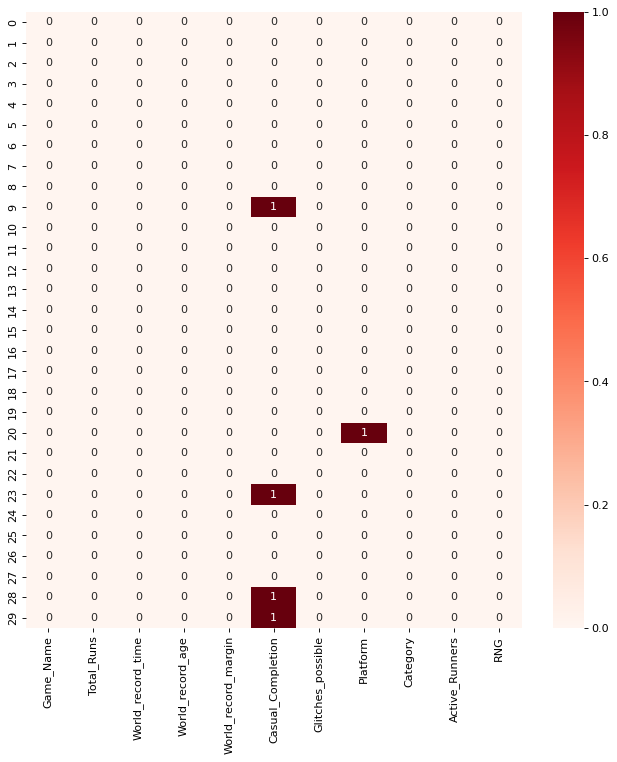

In [76]:
plt.figure(num=None, figsize=(10, 10), dpi=80)
sns.heatmap(data.isnull() ,annot=True, cmap="Reds")

- To ensure that we have a complete dataset for our index we will fill this data by means of the mean value
- I have identified that there are 2 categories that contain missing values, **Casual_Completion** and **Platform**
- There are inconsistencies in my time data, to ensure data is measured fairly, I will convert **World_record_time**, **World_record_margin** and **Casual_Completion** into seconds

In [77]:
data["Casual_Completion"] = data["Casual_Completion"].fillna(data["Casual_Completion"].mean())
data["Platform"]= data["Platform"].fillna(data["Platform"].mode()[0])
data.isnull().sum()

Game_Name              0
Total_Runs             0
World_record_time      0
World_record_age       0
World_record_margin    0
Casual_Completion      0
Glitches_possible      0
Platform               0
Category               0
Active_Runners         0
RNG                    0
dtype: int64

In [78]:
world_record_time_seconds = pd.to_timedelta(data["World_record_time"])
world_record_margin_seconds = pd.to_timedelta(data["World_record_margin"])
casual_completion_seconds = data["Casual_Completion"]*60*60
data["World_record_time"] = world_record_time_seconds.dt.total_seconds()
data["World_record_margin"] = world_record_margin_seconds.dt.total_seconds()
data["Casual_Completion"] = casual_completion_seconds

- Now that I have a complete dataset I need to check for outliers

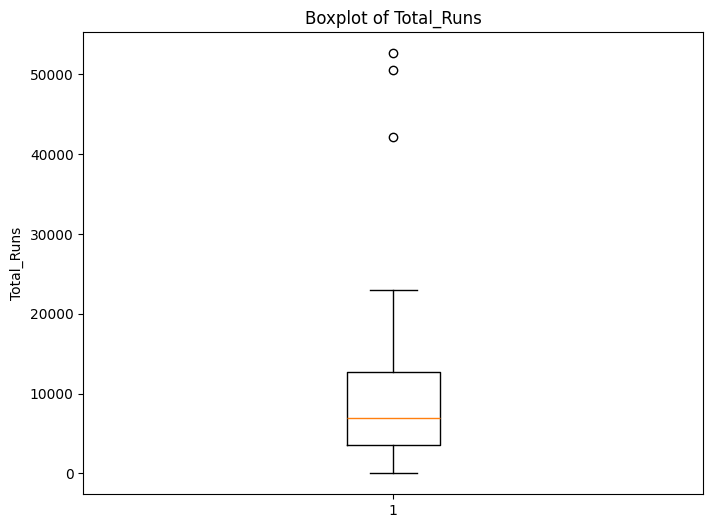

In [79]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.Total_Runs)
plt.title("Boxplot of Total_Runs")
plt.ylabel("Total_Runs")
plt.show()

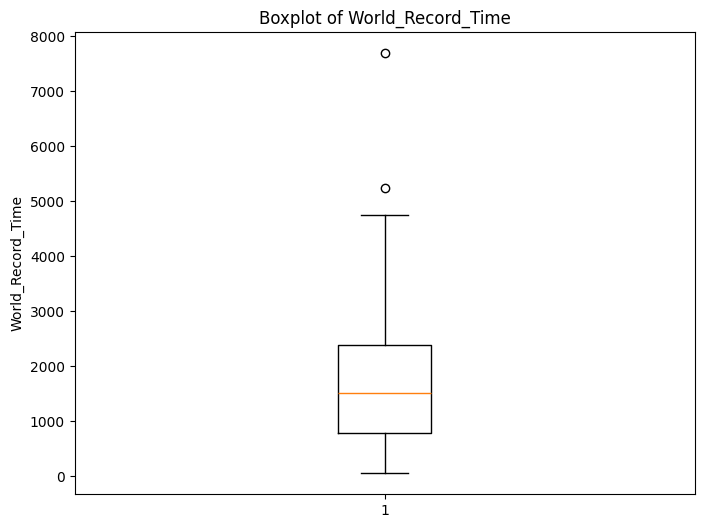

In [80]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.World_record_time)
plt.title("Boxplot of World_Record_Time")
plt.ylabel("World_Record_Time")
plt.show()

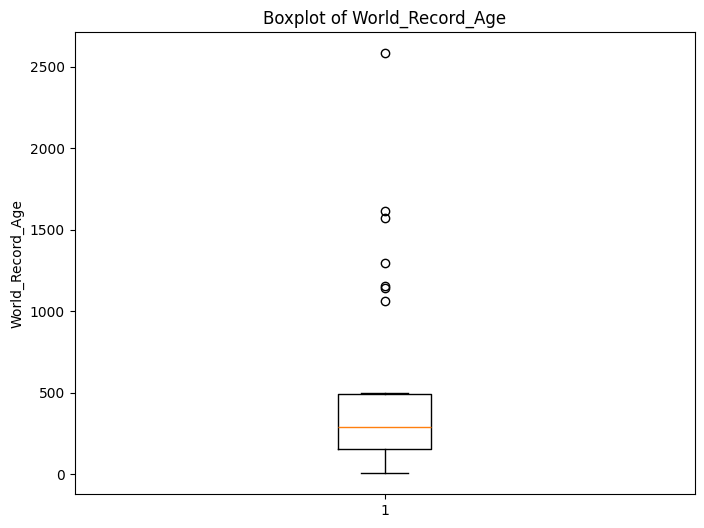

In [81]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.World_record_age)
plt.title("Boxplot of World_Record_Age")
plt.ylabel("World_Record_Age")
plt.show()

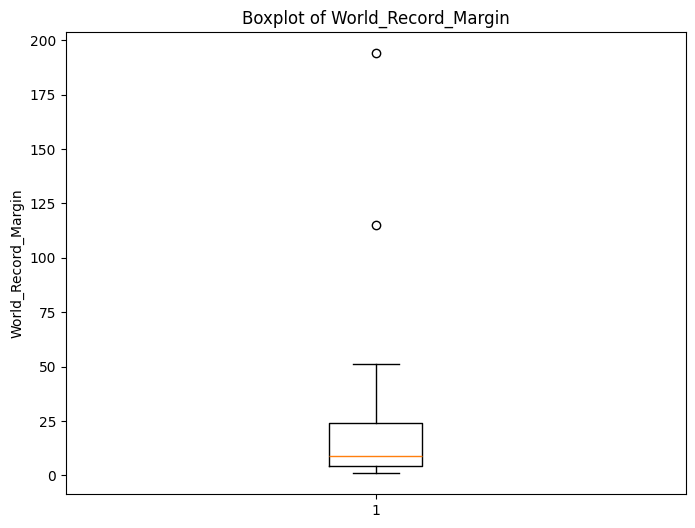

In [82]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.World_record_margin)
plt.title("Boxplot of World_Record_Margin")
plt.ylabel("World_Record_Margin")
plt.show()

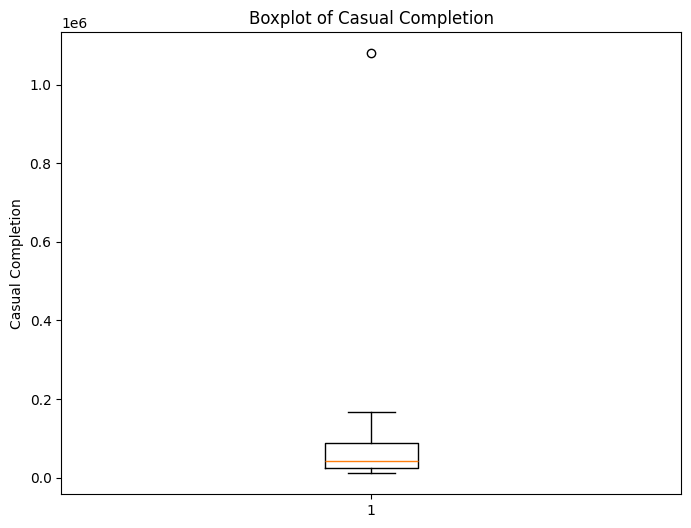

In [83]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.Casual_Completion)
plt.title("Boxplot of Casual Completion")
plt.ylabel("Casual Completion")
plt.show()

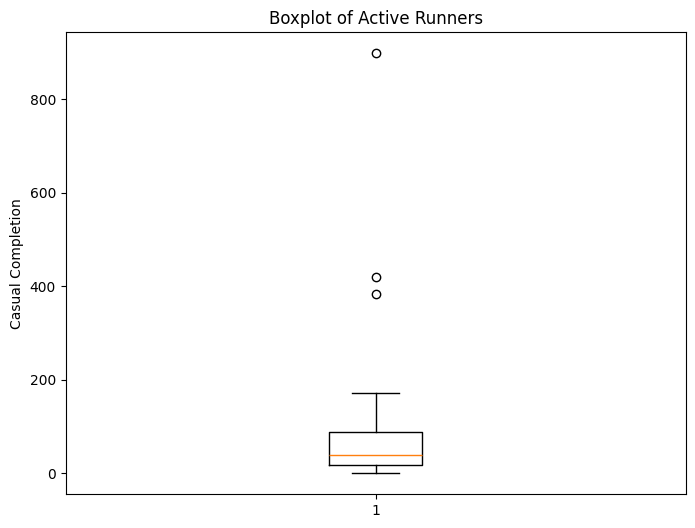

In [84]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.Active_Runners)
plt.title("Boxplot of Active Runners")
plt.ylabel("Casual Completion")
plt.show()

**Multivariate analysis**

Principal component analysis

In [85]:
data.head(30)

,Game_Name,Total_Runs,World_record_time,World_record_age,World_record_margin,Casual_Completion,Glitches_possible,Platform,Category,Active_Runners,RNG
0,Super Mario 64,52653,875.0,1153,1.0,43200.0,Yes,N64,Platformer,384,1
1,Celeste,50501,1488.0,39,15.0,30600.0,No,PC,Platformer,419,1
2,Super Mario Odyssey,22934,3313.0,304,5.0,45000.0,Yes,Switch2,Platformer,172,1
3,Getting over it with Bennett Foddy,15086,58.0,340,1.0,21600.0,No,PC,Platformer,140,1
4,Spongebob Squarepants: Battle for Bikini Bottom,14817,2437.0,241,115.0,36000.0,Yes,Xbox,Platformer,29,1
5,Super Metroid,13932,2422.0,472,14.0,27000.0,Yes,SNES,Platformer,65,1
6,Hollow Knight,13099,1849.0,376,4.0,97200.0,Yes,PC,Platformer,163,1
7,Super Mario World,11247,1938.0,247,2.0,18000.0,Yes,SNES,Platformer,28,1
8,Sonic Adventure 2: Battle,11190,1253.0,1296,5.0,32400.0,Yes,PC,Platformer,47,1
9,Mighty guy 3,2,128.0,1571,10.0,89100.0,No,PC,Platformer,0,1


In [86]:
from sklearn.decomposition import PCA
from sklearn import preprocessing

- Separating the categorical variables from the numerical variables

In [87]:
numerical_data = data.copy()
numerical_data.drop('Game_Name', axis = 1, inplace = True)
numerical_data.drop('Glitches_possible', axis = 1, inplace = True)
numerical_data.drop('Platform', axis = 1, inplace = True)
numerical_data.drop('Category', axis = 1, inplace = True)
numerical_data.drop('RNG', axis = 1, inplace = True)
# data.head()
# scaled_data = preprocessing.scale(data.T)
# scaled_data

In [88]:
numerical_data.head()

,Total_Runs,World_record_time,World_record_age,World_record_margin,Casual_Completion,Active_Runners
0,52653,875.0,1153,1.0,43200.0,384
1,50501,1488.0,39,15.0,30600.0,419
2,22934,3313.0,304,5.0,45000.0,172
3,15086,58.0,340,1.0,21600.0,140
4,14817,2437.0,241,115.0,36000.0,29


In [89]:
scaled_data = preprocessing.scale(numerical_data)

scaled_data

array([[ 3.07606716e+00, -5.80782751e-01,  1.05234899e+00,
        -5.65924655e-01, -2.44514105e-01,  1.58840507e+00],
       [ 2.91628432e+00, -2.29505172e-01, -8.18568299e-01,
        -2.08498557e-01, -3.11635624e-01,  1.78545437e+00],
       [ 8.69475052e-01,  8.16304912e-01, -3.73511674e-01,
        -4.63802913e-01, -2.34925317e-01,  3.94849275e-01],
       [ 2.86772578e-01, -1.04896184e+00, -3.13051151e-01,
        -5.65924655e-01, -3.59579566e-01,  2.14689910e-01],
       [ 2.66799723e-01,  3.14316072e-01, -4.79317589e-01,
         2.34454500e+00, -2.82869259e-01, -4.10237888e-01],
       [ 2.01089772e-01,  3.05720372e-01, -9.13625677e-02,
        -2.34028993e-01, -3.30813201e-01, -2.07558602e-01],
       [ 1.39240746e-01, -2.26353415e-02, -2.52590628e-01,
        -4.89333349e-01,  4.31495480e-02,  3.44179454e-01],
       [ 1.73246573e-03,  2.83658077e-02, -4.69240835e-01,
        -5.40394220e-01, -3.78757143e-01, -4.15867868e-01],
       [-2.49970056e-03, -3.64171128e-01,  1.292

In [90]:
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)
per_var = np.round(pca.explained_variance_ratio_ *100, decimals =1)
per_var

array([36.1, 23.7, 17.1, 15.3,  4.9,  2.8])

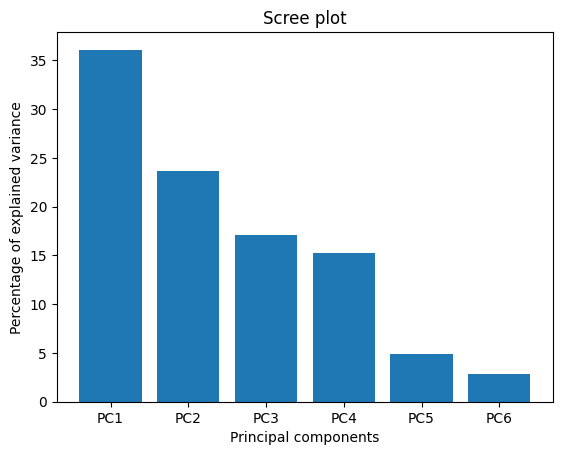

In [91]:
labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]
plt.bar(x = range(1, len(per_var)+1), height = per_var, tick_label=labels)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principal components")
plt.title("Scree plot")
plt.show()

In [92]:
pca.explained_variance_

array([2.23950035, 1.47395979, 1.06366341, 0.95086299, 0.30526642,
       0.17364359])

 - The Kaiser Criterion states that you should keep principal components which eigenvalues > 1, in this case I will keep PC 1,2 and 3

In [93]:
pca = PCA(n_components=3)
updated_pca = pca.fit_transform(scaled_data)
updated_pca.shape

(30, 3)

**Cluster Analysis**

In [94]:
from sklearn.cluster import KMeans
data.head()

,Game_Name,Total_Runs,World_record_time,World_record_age,World_record_margin,Casual_Completion,Glitches_possible,Platform,Category,Active_Runners,RNG
0,Super Mario 64,52653,875.0,1153,1.0,43200.0,Yes,N64,Platformer,384,1
1,Celeste,50501,1488.0,39,15.0,30600.0,No,PC,Platformer,419,1
2,Super Mario Odyssey,22934,3313.0,304,5.0,45000.0,Yes,Switch2,Platformer,172,1
3,Getting over it with Bennett Foddy,15086,58.0,340,1.0,21600.0,No,PC,Platformer,140,1
4,Spongebob Squarepants: Battle for Bikini Bottom,14817,2437.0,241,115.0,36000.0,Yes,Xbox,Platformer,29,1


 - By using k means clustering, I can quickly group my data together
 - To find out the optimal k for clustering, I used [Zach Bobbitt's guide ](https://www.statology.org/elbow-method-in-python/)to implement th elbow method and verify the optimal k
 - From the graph generated, I found that the elbow begins at k=4, therefore indicating that 4 clusters will be used to group the data

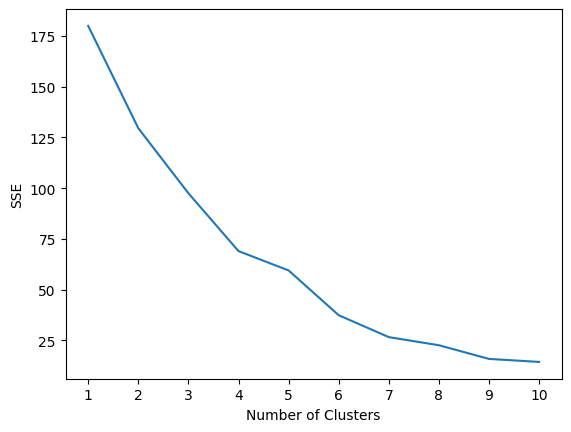

In [127]:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

#visualize results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [121]:
km = KMeans(n_clusters=4, n_init='auto')
km

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [122]:
y_predicted = km.fit_predict(updated_pca)
y_predicted
data['cluster'] = y_predicted
data['PC1'] = updated_pca[:, 0]
data['PC2'] = updated_pca[:, 1]
data

,Game_Name,Total_Runs,World_record_time,World_record_age,World_record_margin,Casual_Completion,Glitches_possible,Platform,Category,Active_Runners,RNG,cluster,PC1,PC2
0,Super Mario 64,52653,875.0,1153,1.0,43200.0,Yes,N64,Platformer,384,1,1,2.774414,2.005677
1,Celeste,50501,1488.0,39,15.0,30600.0,No,PC,Platformer,419,1,1,2.990677,1.340815
2,Super Mario Odyssey,22934,3313.0,304,5.0,45000.0,Yes,Switch2,Platformer,172,1,0,0.733530,0.365532
3,Getting over it with Bennett Foddy,15086,58.0,340,1.0,21600.0,No,PC,Platformer,140,1,0,1.016812,-0.482972
4,Spongebob Squarepants: Battle for Bikini Bottom,14817,2437.0,241,115.0,36000.0,Yes,Xbox,Platformer,29,1,2,-1.066013,1.114721
5,Super Metroid,13932,2422.0,472,14.0,27000.0,Yes,SNES,Platformer,65,1,0,0.056520,0.010915
6,Hollow Knight,13099,1849.0,376,4.0,97200.0,Yes,PC,Platformer,163,1,0,0.546923,-0.225649
7,Super Mario World,11247,1938.0,247,2.0,18000.0,Yes,SNES,Platformer,28,1,0,0.163111,-0.575252
8,Sonic Adventure 2: Battle,11190,1253.0,1296,5.0,32400.0,Yes,PC,Platformer,47,1,0,-0.120911,0.285540
9,Mighty guy 3,2,128.0,1571,10.0,89100.0,No,PC,Platformer,0,1,0,-0.704181,-0.114700


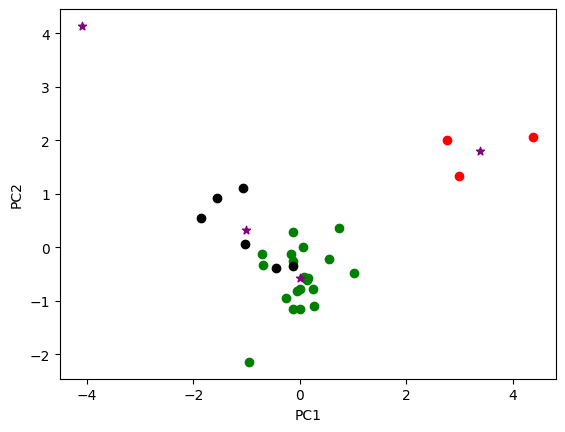

In [124]:
df0 = data[data.cluster == 0]
df1 = data[data.cluster == 1]
df2 = data[data.cluster == 2]
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.scatter(df0.PC1, df0.PC2, color='green')
plt.scatter(df1.PC1, df1.PC2, color='red')
plt.scatter(df2.PC1, df2.PC2, color='black')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='purple', marker='*', label='centroid')



- This graph separates the data into 4 distinct groups
- Green is the largest group which with its point quite dense together
- Black is the second largest with its point surrounding the nearest centroid
- Red is smaller and further away from the rest of the data
- We have a single point cluster in the top left of the graph, it appears to be an anomaly